# Predictive power — MN/TSRV noise stack

OOS chronological split on Pass 2.7 panel: features_t → targets_{t+1}.

**Gates:** late \|CI_lo\| > 0.10 · n≥30 · early same-sign; noise→RV needs encompassing vs sparse persistence.

**SoT:** `out/depth_predict/depth_predict.json` · Desk [`../DESK_MEMO.md`](../DESK_MEMO.md)


In [1]:
from pathlib import Path
import os
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = (Path(os.environ.get('ARES_MICROSTRUCTURE') or (Path.home() / 'srv' / 'ares-microstructure')) / 'research' / 'books' / 'mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # ares-microstructure root

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
ep = jload('expand_panel/expand_panel.json')
dp = jload('depth_predict/depth_predict.json') if (OUT/'depth_predict'/'depth_predict.json').exists() else {}
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))
print('expand n_ok', ep['coverage']['n_ok'], 'depth keys', list(dp.keys())[:8])


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_info_heatmap.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_acf_lag1.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_pred_board.png', 'fig_pred_ic_noise.png', 'fig_ratio_hist.png', 'fig_signature.png', 'fig_tob_coverage.png', 'fig_tod_acf.png', 'fig_tsrv_oos.png', 'fig_venue_mid_taxonomy.png', 'signal_board.png']
expand n_ok 204 depth keys ['meta', 'information', 'predictive', 'taxonomy', 'tape_depth', 'uses', 'figures', 'decisions_rollup']


## 1. Protocol


In [2]:
pred = dp['predictive']
print('n_pairs', pred['n_pairs'], 'early', pred['n_early'], 'late', pred['n_late'], 'split', pred['split_day'])
print('horizons', pred['horizons'])
print('crash/V:', pred.get('crash_v_note'))


n_pairs 180 early 86 late 94 split 2026-09-13
horizons {'next_day': 1, 'units': 'UTC venue-day'}
crash/V: crash/V flags not in expand_panel; skipped (no cross_miniflash SSM join on this pass)


## 2. Decision board


**Predictive decisions** — `out/desk_synthesis/figs/fig_pred_board.png`

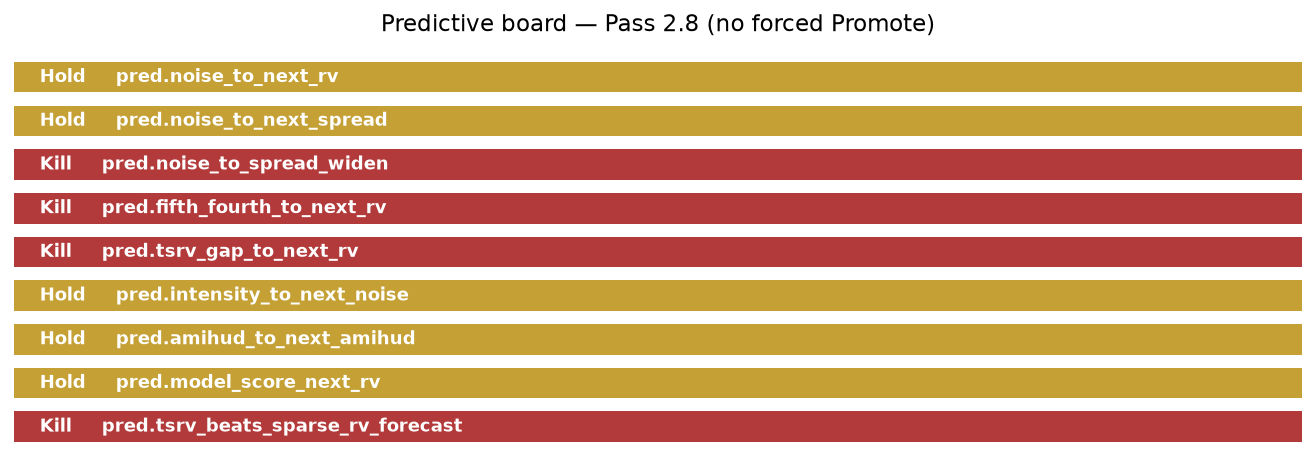

,id,decision,why
0,pred.noise_to_next_rv,Hold,Raw OOS IC clears gate but encompassing fails:...
1,pred.noise_to_next_spread,Hold,OOS late same-sign but gate incomplete: late ρ...
2,pred.noise_to_spread_widen,Kill,"OOS late IC CI through 0: ρ=0.038 CI=[-0.218,0..."
3,pred.fifth_fourth_to_next_rv,Kill,"OOS late IC CI through 0: ρ=-0.091 CI=[-0.312,..."
4,pred.tsrv_gap_to_next_rv,Kill,"OOS late IC CI through 0: ρ=-0.152 CI=[-0.368,..."
5,pred.intensity_to_next_noise,Hold,OOS late same-sign but gate incomplete: late ρ...
6,pred.amihud_to_next_amihud,Hold,Amihud persistence clears IC gate but is liqui...
7,pred.model_score_next_rv,Hold,OOS late same-sign but gate incomplete: late ρ...
8,pred.tsrv_beats_sparse_rv_forecast,Kill,DM late prefer=sparse t=-1.997244766311049 n=94.0


{'Hold': 5, 'Kill': 4}


In [3]:
show_fig('fig_pred_board.png', 'Predictive decisions')
rows = [{'id': k, **{kk: vv for kk, vv in v.items() if kk in ('decision','why')}} for k, v in pred['decisions'].items()]
display(pd.DataFrame(rows))
print(pd.Series([r['decision'] for r in rows]).value_counts().to_dict())


## 3. OOS IC — noise_std → next-day targets


**IC forest** — `out/desk_synthesis/figs/fig_pred_ic_noise.png`

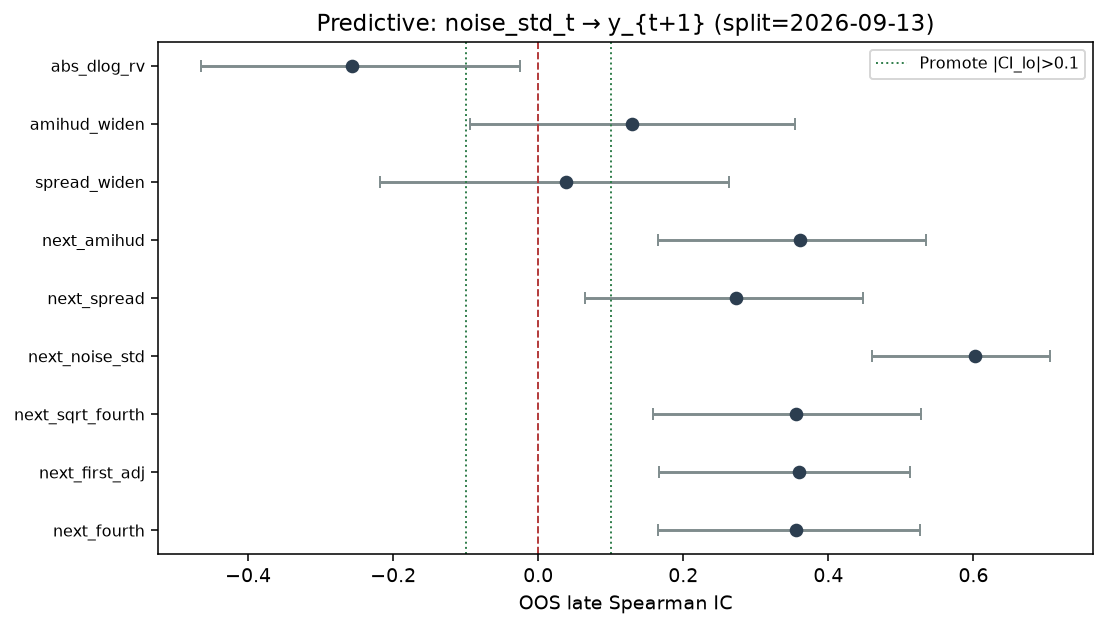

,target,late_rho,late_lo,late_hi,early_rho,early_lo,early_hi,n_late
0,y_next_fourth,0.355084,0.165083,0.525987,0.277211,0.062951,0.463137,94.0
1,y_next_first_adj,0.358913,0.166992,0.512632,0.295665,0.076302,0.487940,94.0
2,y_next_sqrt_fourth,0.355084,0.158178,0.527242,0.277211,0.072989,0.468967,94.0
3,y_next_noise_std,0.601575,0.460690,0.705948,0.480900,0.285203,0.633591,94.0
4,y_next_spread,0.272832,0.064040,0.448422,-0.650324,-0.811107,-0.414110,77.0
5,y_next_amihud,0.361110,0.164663,0.535164,0.476164,0.304803,0.608374,94.0
6,y_spread_widen,0.038327,-0.217909,0.262663,-0.204603,-0.517057,0.110246,69.0
7,y_amihud_widen,0.129560,-0.093651,0.353618,-0.010161,-0.222265,0.222671,94.0
8,y_abs_dlog_rv,-0.257133,-0.465120,-0.024522,0.013425,-0.186127,0.232543,94.0


In [4]:
show_fig('fig_pred_ic_noise.png', 'IC forest')
late = pred['ic_late_oos']['x_noise_std']
early = pred['ic_early']['x_noise_std']
df = pd.DataFrame({
    'target': list(late.keys()),
    'late_rho': [late[k]['rho'] for k in late],
    'late_lo': [late[k]['lo'] for k in late],
    'late_hi': [late[k]['hi'] for k in late],
    'early_rho': [early[k]['rho'] for k in early],
    'early_lo': [early[k]['lo'] for k in early],
    'early_hi': [early[k]['hi'] for k in early],
    'n_late': [late[k]['n'] for k in late],
})
display(df)


## 4. Encompassing — noise vs sparse RV persistence


In [5]:
enc = pred.get('encompassing_noise_vs_sparse', {})
display(pd.DataFrame(enc).T)
print('Hold rationale: noise⊥fourth partial IC ≈ 0 on late → vol clustering, not Êε alpha')


,n,noise_partial_ic,fourth_partial_ic,noise_raw_ic,fourth_raw_ic
early,86.0,-0.003142,0.290551,0.277211,0.386160
late_oos,94.0,0.064610,0.247668,0.355084,0.427143


Hold rationale: noise⊥fourth partial IC ≈ 0 on late → vol clustering, not Êε alpha


## 5. Diebold–Mariano — sparse vs TSRV persistence


In [6]:
dm = pred['diebold_mariano']
display(pd.DataFrame(dm['next_fourth_persistence']).T)
display(pd.DataFrame(dm['next_first_adj_persistence']).T)
print('decision:', pred['decisions']['pred.tsrv_beats_sparse_rv_forecast'])


,n,mean_d,t,ci95,prefer,note
all,180.0,0.0,0.956578,"[-8.880117955682944e-09, 4.7914432350898447e-08]",tie,d=err_sparse_sq-err_tsrv_sq; >0 ⇒ err_sparse_s...
early,86.0,0.0,1.524194,"[5.3967376525877e-10, 1.2145464645417333e-07]",tie,d=err_sparse_sq-err_tsrv_sq; >0 ⇒ err_sparse_s...
late_oos,94.0,-0.0,-1.997245,"[-2.9367796424669494e-08, -6.277988094833541e-10]",sparse,d=err_sparse_sq-err_tsrv_sq; >0 ⇒ err_sparse_s...


,n,mean_d,t,ci95,prefer,note
all,180.0,0.0,0.965763,"[-8.331666568180193e-09, 4.942447389021928e-08]",tie,d=err_sparse_fa_sq-err_tsrv_fa_sq; >0 ⇒ err_sp...
late_oos,94.0,-0.0,-2.116816,"[-2.9996397516235794e-08, -2.1474327329780486e...",sparse,d=err_sparse_fa_sq-err_tsrv_fa_sq; >0 ⇒ err_sp...


decision: {'decision': 'Kill', 'why': 'DM late prefer=sparse t=-1.997244766311049 n=94.0', 'dm_late': {'n': 94.0, 'mean_d': -1.4462859025779148e-08, 't': -1.997244766311049, 'ci95': [-2.9367796424669494e-08, -6.277988094833541e-10], 'prefer': 'sparse', 'note': 'd=err_sparse_sq-err_tsrv_sq; >0 ⇒ err_sparse_sq worse'}}


## 6. Multi-feature score (early signs → late)


In [7]:
ms = pred['model_score_oos']
display(pd.DataFrame(ms).T)
print('pred.model_score_next_rv:', pred['decisions']['pred.model_score_next_rv']['why'])


,n,rho,lo,hi,signs
y_next_fourth,94.0,0.266409,0.049411,0.461811,"{'x_noise_std': 1.0, 'x_fifth_over_fourth': -1..."
y_next_spread,77.0,0.376413,0.170719,0.542067,"{'x_noise_std': 1.0, 'x_fifth_over_fourth': -1..."
y_spread_widen,69.0,0.105444,-0.151271,0.363932,"{'x_noise_std': 1.0, 'x_fifth_over_fourth': -1..."
y_abs_dlog_rv,94.0,-0.013922,-0.234598,0.174031,"{'x_noise_std': 1.0, 'x_fifth_over_fourth': -1..."
y_next_amihud,94.0,0.227468,-0.01047,0.424949,"{'x_noise_std': 1.0, 'x_fifth_over_fourth': -1..."


pred.model_score_next_rv: OOS late same-sign but gate incomplete: late ρ=0.266 CI=[0.049,0.462]; early ρ=nan CI=[nan,nan] n=94
